# Brain Tumor Classification with MobileNetV3Large (Fine-Tuning)

Dataset: [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

This notebook follows the same pipeline structure as the VGG16/EfficientNetB0/ResNet50/DenseNet121 versions, but swaps in **MobileNetV3Large** as the backbone and uses the same **two-phase transfer learning + fine-tuning** strategy (feature extraction first, then fine-tuning the top layers with a low learning rate).

> Note: Keras ships `MobileNetV3Small` and `MobileNetV3Large`. Large is used here — it is still lightweight (~5.4M params) compared to ResNet50/DenseNet121, but gives noticeably better accuracy than Small, which trades accuracy for extreme size/speed reduction meant for mobile/embedded deployment (not needed for a locally-trained project like this).

In [1]:
import os
import numpy as np
import random
import json
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, BatchNormalization, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import shuffle
import matplotlib.pyplot as plt


In [2]:
train_dir = r"dataset/Training"
test_dir  = r"dataset/Testing"

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


In [3]:
# Define CLASS_LABELS ONCE using sorted() so order is always consistent
CLASS_LABELS = sorted(os.listdir(train_dir))
print("Class label order (fixed):", CLASS_LABELS)
print(f"Number of classes: {len(CLASS_LABELS)}")


Class label order (fixed): ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


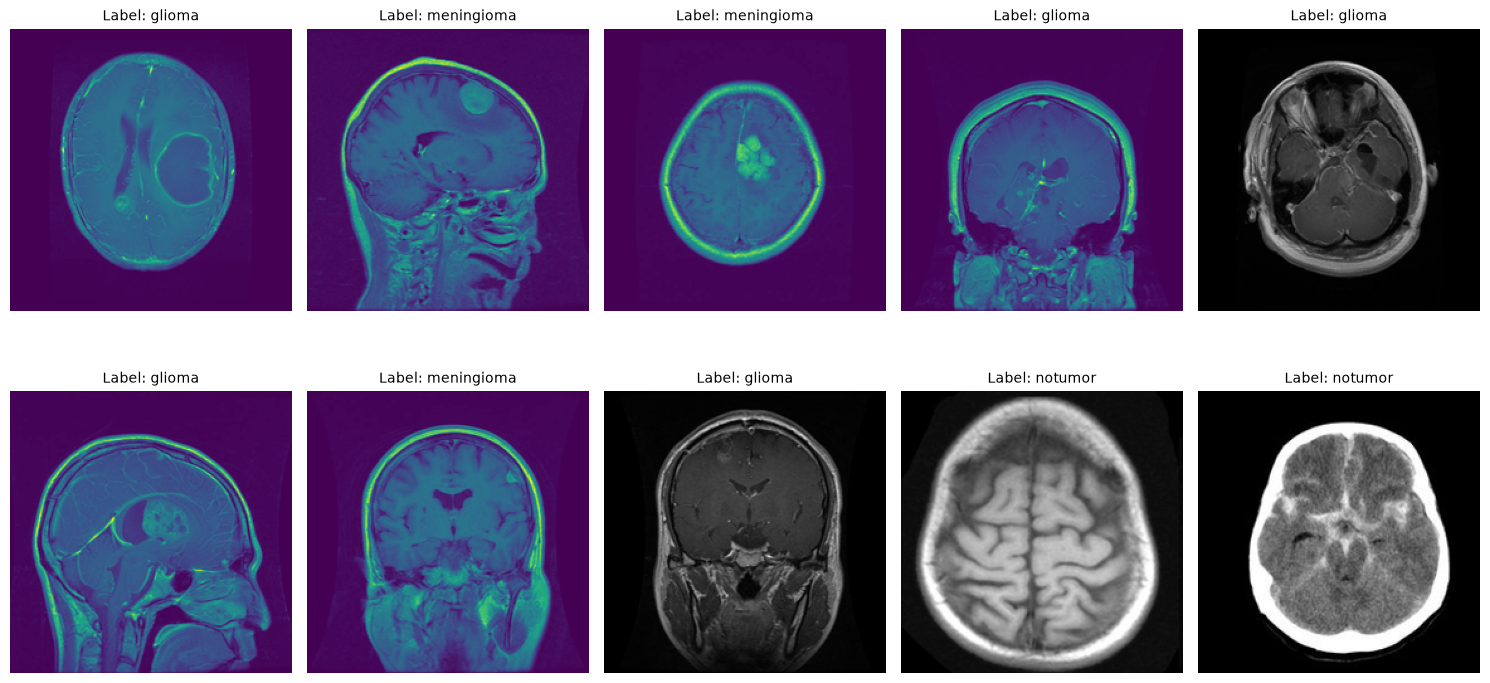

In [4]:
# Visualize some training samples
random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img = Image.open(train_paths[idx]).resize((224, 224))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()


## Image loading & augmentation

MobileNetV3Large expects images sized **224x224**. Its `preprocess_input` is actually a passthrough (scaling/normalization is built into the model's first layer as a `Rescaling` layer), but we still call it for consistency and forward-compatibility — **do not** manually rescale to [0, 1] yourself on top of it.

In [5]:
IMAGE_SIZE = 224  # MobileNetV3Large default input size

# Image Augmentation
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image)
    return image

# Load images (kept in raw 0-255 range; preprocess_input handles normalization)
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = img_to_array(image)
        image = augment_image(image)
        images.append(image)
    images = np.array(images)
    return preprocess_input(images)


def encode_label(labels):
    return np.array([CLASS_LABELS.index(label) for label in labels])

# Data generator
def datagen(paths, labels, batch_size=20, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths  = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = encode_label(labels[i:i + batch_size])
            yield batch_images, batch_labels


## Build the model

**Phase 1 — Feature extraction:** freeze the entire MobileNetV3Large backbone and train only the new classification head.

**Phase 2 — Fine-tuning:** unfreeze the top block(s) of the backbone and continue training with a much smaller learning rate, so the pretrained ImageNet features are nudged toward MRI features instead of being destroyed. MobileNetV3Large is built from lightweight inverted-residual "bottleneck" blocks, so we unfreeze proportionally — roughly the last few bottleneck blocks, which hold the most task-specific features.

In [6]:
# Build Model
base_model = MobileNetV3Large(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Phase 1: freeze the entire backbone
base_model.trainable = False

inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(len(CLASS_LABELS), activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,123,716 (11.92 MB)

 Trainable params: 125,444 (490.02 KB)

 Non-trainable params: 2,998,272 (11.44 MB)

### Phase 1 training — train the classification head only

In [7]:
# Train the Model (Phase 1: frozen backbone)
batch_size = 20
epochs_phase1 = 5
steps = int(len(train_paths) / batch_size)

history1 = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs_phase1),
    epochs=epochs_phase1,
    steps_per_epoch=steps
)


Epoch 1/5


/opt/miniconda3/envs/image_classification/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a generator. The generator is expected to yield already-shuffled data.
  self.data_adapter = data_adapters.get_data_adapter(


280/280 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - loss: 0.4875 - sparse_categorical_accuracy: 0.8295
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 65s 233ms/step - loss: 0.2537 - sparse_categorical_accuracy: 0.9039
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 115s 411ms/step - loss: 0.1960 - sparse_categorical_accuracy: 0.9304
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 116s 415ms/step - loss: 0.1553 - sparse_categorical_accuracy: 0.9420
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 108s 387ms/step - loss: 0.1287 - sparse_categorical_accuracy: 0.9498


### Phase 2 training — unfreeze top layers and fine-tune

Unfreeze the last ~20 layers of MobileNetV3Large (the final bottleneck blocks, which learn the most task-specific features) and continue training with a low learning rate.

In [8]:
# Phase 2: unfreeze the top layers of the backbone for fine-tuning
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 20  # unfreeze last 20 layers (~final bottleneck blocks)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNorm layers frozen even inside the unfrozen block (MobileNetV3 uses BatchNorm after
# most conv layers in its bottleneck blocks, same reasoning as the other backbones)
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # much smaller LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,123,716 (11.92 MB)

 Trainable params: 1,072,244 (4.09 MB)

 Non-trainable params: 2,051,472 (7.83 MB)

In [9]:
epochs_phase2 = 10

callbacks = [
    EarlyStopping(monitor='loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='loss', factor=0.5, patience=2, min_lr=1e-7)
]

history2 = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs_phase2),
    epochs=epochs_phase2,
    steps_per_epoch=steps,
    callbacks=callbacks
)


Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 130s 452ms/step - loss: 0.1093 - sparse_categorical_accuracy: 0.9596 - learning_rate: 1.0000e-05
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 144s 516ms/step - loss: 0.0953 - sparse_categorical_accuracy: 0.9638 - learning_rate: 1.0000e-05
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 134s 480ms/step - loss: 0.0860 - sparse_categorical_accuracy: 0.9673 - learning_rate: 1.0000e-05
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 142s 509ms/step - loss: 0.0711 - sparse_categorical_accuracy: 0.9762 - learning_rate: 1.0000e-05
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 145s 516ms/step - loss: 0.0692 - sparse_categorical_accuracy: 0.9773 - learning_rate: 1.0000e-05
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 131s 468ms/step - loss: 0.0654 - sparse_categorical_accuracy: 0.9768 - learning_rate: 1.0000e-05
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 101s 360ms/step - loss: 0.0625 - sparse_categorical_accuracy: 0.9800 - learning_rate: 1.0000e-05
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 7

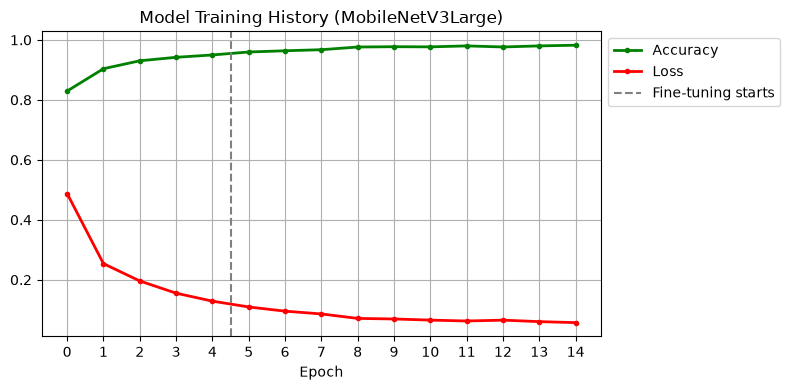

In [10]:
# Combine history from both phases for plotting
acc = history1.history['sparse_categorical_accuracy'] + history2.history['sparse_categorical_accuracy']
loss = history1.history['loss'] + history2.history['loss']
total_epochs = epochs_phase1 + len(history2.history['loss'])

plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(acc, '.g-', linewidth=2)
plt.plot(loss, '.r-', linewidth=2)
plt.axvline(x=epochs_phase1 - 0.5, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Model Training History (MobileNetV3Large)')
plt.xlabel('Epoch')
plt.xticks(range(total_epochs))
plt.legend(['Accuracy', 'Loss', 'Fine-tuning starts'], loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


In [11]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate on test data
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)
predicted_classes = np.argmax(test_predictions, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, predicted_classes, target_names=CLASS_LABELS))


50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 372ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.77      0.86       400
  meningioma       0.86      0.93      0.90       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



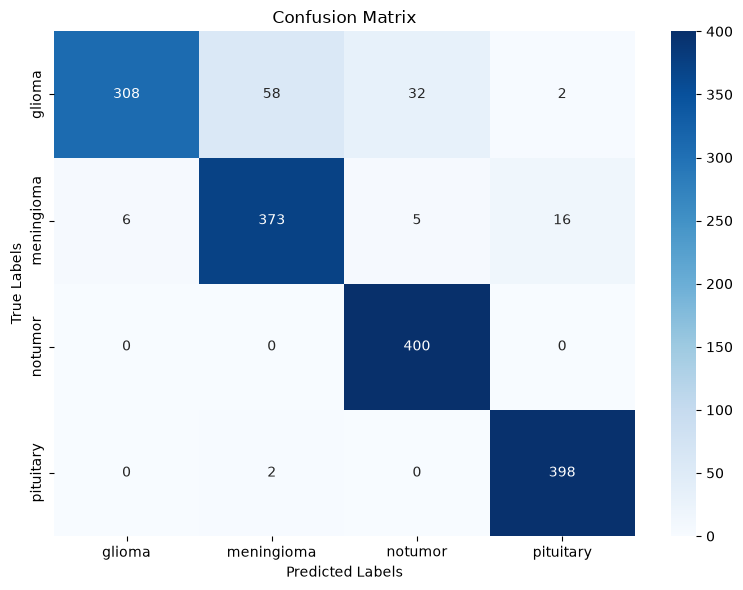

In [12]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()


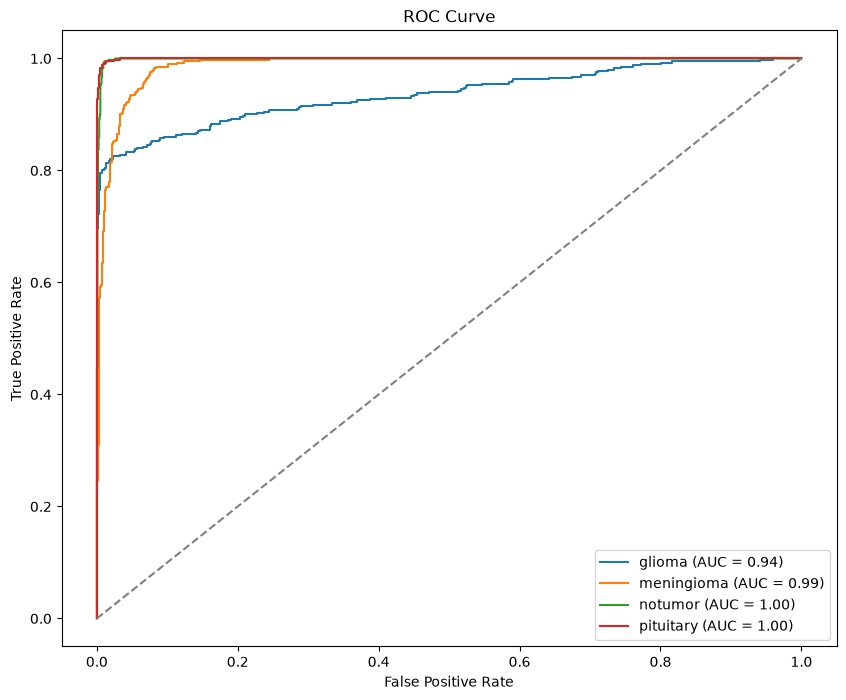

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ROC Curve
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(CLASS_LABELS)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(CLASS_LABELS)):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(len(CLASS_LABELS)):
    plt.plot(fpr[i], tpr[i], label=f'{CLASS_LABELS[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


In [14]:
# Save the model
model.save('model_mobilenetv3large.keras')
print("Model saved as model_mobilenetv3large.keras")

# Also save CLASS_LABELS so you can load them later without retraining
with open('class_labels.json', 'w') as f:
    json.dump(CLASS_LABELS, f)
print("Class labels saved as class_labels.json:", CLASS_LABELS)


Model saved as model_mobilenetv3large.keras
Class labels saved as class_labels.json: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [15]:
# Load model (optional — run only if restarting kernel)
model = load_model('model_mobilenetv3large.keras')

with open('class_labels.json') as f:
    CLASS_LABELS = json.load(f)

print("Model loaded. Class labels:", CLASS_LABELS)



Model loaded. Class labels: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [16]:
# Prediction function
def detect_and_display(img_path, model, image_size=224):
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_index = np.argmax(predictions, axis=1)[0]
        confidence = np.max(predictions, axis=1)[0]

        predicted_label = CLASS_LABELS[predicted_index]

        if predicted_label == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {predicted_label}"

        # Show all class probabilities
        print("Probabilities:")
        for i, label in enumerate(CLASS_LABELS):
            print(f"  {label}: {predictions[0][i]*100:.2f}%")

        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
Probabilities:
  glioma: 0.00%
  meningioma: 0.00%
  notumor: 100.00%
  pituitary: 0.00%


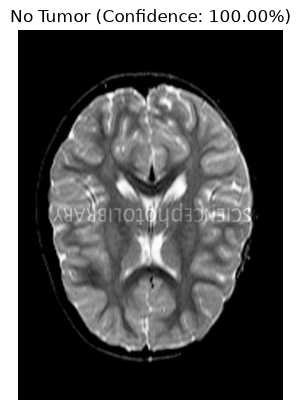

In [22]:
# Test prediction — No Tumor
image_path = r'dataset/Testing/notumor/Te-no_5.jpg' 
detect_and_display(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Probabilities:
  glioma: 0.00%
  meningioma: 0.01%
  notumor: 0.00%
  pituitary: 99.99%


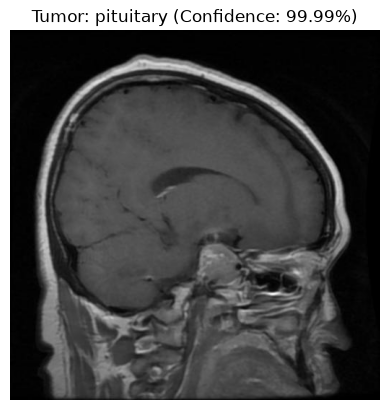

In [23]:
# Test prediction — Pituitary Tumor
image_path = r'dataset/Testing/pituitary/Te-pi_7.jpg'
detect_and_display(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Probabilities:
  glioma: 0.05%
  meningioma: 99.41%
  notumor: 0.00%
  pituitary: 0.55%


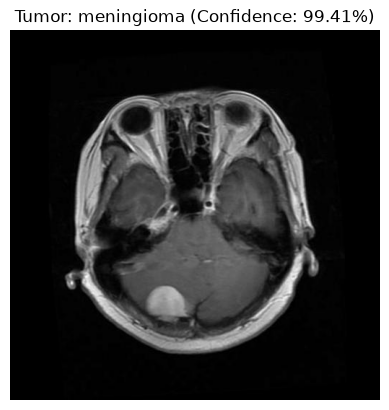

In [24]:
# Test prediction — Meningioma Tumor
image_path = r'dataset/Testing/meningioma/Te-aug-me_4.jpg'
detect_and_display(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Probabilities:
  glioma: 0.01%
  meningioma: 0.12%
  notumor: 0.00%
  pituitary: 99.87%


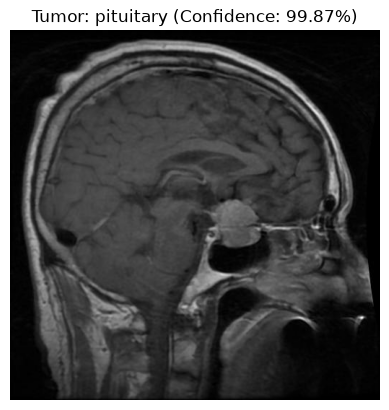

In [25]:
# Test prediction — Pituitary Tumor
image_path = r'dataset/Testing/pituitary/Te-pi_16.jpg'
detect_and_display(image_path, model)


In [21]:
pip install tensorflow 

Note: you may need to restart the kernel to use updated packages.
